# 变分自编码器 (VAE) 深度解析 - PyTorch实现

本Notebook基于 PyImageSearch 的教程 [A Deep Dive into Variational Autoencoders with PyTorch](https://pyimagesearch.com/2023/10/02/a-deep-dive-into-variational-autoencoders-with-pytorch/)


### VAE vs 传统卷积自编码器 (CAE)

| 特性 | 卷积自编码器 (CAE) | 变分自编码器 (VAE) |
|------|-------------------|-------------------|
| 潜在空间 | 确定性（固定点） | 概率性（分布） |
| 编码器输出 | 潜在向量 z | 均值 μ 和对数方差 log(σ²) |
| 损失函数 | 仅重构损失 | 重构损失 + KL散度 |
| 生成能力 | 有限（需要手动选择点） | 强（可从分布采样） |
| 插值能力 | 可能不连续 | 连续平滑 |

## 1. 环境配置与导入

首先安装必要的库并导入模块。

In [ ]:
# 安装必要的库（在Colab中通常已预装）
!pip install torch torchvision matplotlib numpy -q

# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions.normal import Normal
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os

# 设置随机种子以保证可复现性
torch.manual_seed(42)
np.random.seed(42)

# 检查可用设备
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"使用设备: {DEVICE}")

使用设备: cpu


## 2. 超参数配置

定义模型和训练的超参数。

In [ ]:
# 模型超参数
LR = 0.001                    # 学习率
PATIENCE = 2                  # 学习率调度器的耐心值
IMAGE_SIZE = 32               # 输入图像尺寸（28x28 pad到32x32）
CHANNELS = 1                  # 图像通道数（灰度图为1）
BATCH_SIZE = 64               # 批量大小
EMBEDDING_DIM = 2             # 潜在空间维度（2维便于可视化）
EPOCHS = 50                   # 训练轮数（可根据需要调整）
SHAPE_BEFORE_FLATTENING = (128, IMAGE_SIZE // 8, IMAGE_SIZE // 8)  # (128, 4, 4)

# Fashion-MNIST 类别标签
CLASS_LABELS = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

print(f"潜在空间维度: {EMBEDDING_DIM}")
print(f"批次大小: {BATCH_SIZE}")
print(f"训练轮数: {EPOCHS}")

潜在空间维度: 2
批次大小: 64
训练轮数: 50


## 3. VAE 损失函数

VAE 的损失函数由两部分组成：

### 3.1 重构损失 (Reconstruction Loss)

衡量重构图像与原始图像之间的差异，使用二元交叉熵（BCE）：

$$\mathcal{L}_{\text{recon}} = \frac{1}{N} \sum_{i=1}^{N} \text{BCE}(x_i, \hat{x}_i)$$

其中 $x_i$ 是原始图像，$\hat{x}_i$ 是重构图像。

### 3.2 KL 散度 (Kullback-Leibler Divergence)

衡量编码器学到的分布 $q(z|x)$ 与标准正态分布 $p(z)$ 之间的差异：

$$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

其中 $\mu_j$ 和 $\sigma_j$ 分别是潜在变量的均值和标准差。

### 3.3 总损失

$$\mathcal{L}_{\text{VAE}} = \lambda \cdot \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}$$

其中 $\lambda$ 是重构损失的权重（本实现中使用 500）。

In [ ]:
def vae_gaussian_kl_loss(mu, logvar):
    """
    计算KL散度损失

    参考: Appendix B from VAE paper:
    Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    https://arxiv.org/abs/1312.6114

    参数:
        mu: 潜在分布的均值 [batch_size, embedding_dim]
        logvar: 潜在分布的对数方差 [batch_size, embedding_dim]

    返回:
        KL散度的平均值
    """
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return KLD.mean()


def reconstruction_loss(x_reconstructed, x):
    """
    计算重构损失（二元交叉熵）

    参数:
        x_reconstructed: 重构的图像 [batch_size, channels, height, width]
        x: 原始图像 [batch_size, channels, height, width]
    """
    bce_loss = nn.BCELoss()
    return bce_loss(x_reconstructed, x)


def vae_loss(y_pred, y_true):
    """
    VAE总损失函数 = 重构损失 + KL散度

    参数:
        y_pred: 元组 (mu, logvar, recon_x)
        y_true: 原始输入图像
    """
    mu, logvar, recon_x = y_pred
    recon_loss = reconstruction_loss(recon_x, y_true)
    kld_loss = vae_gaussian_kl_loss(mu, logvar)
    # 重构损失乘以权重500以平衡两部分损失
    return 500 * recon_loss + kld_loss

## 4. 重参数化技巧 (Reparameterization Trick)

VAE 中的一个关键挑战是如何对采样操作进行反向传播。直接从分布中采样会阻断梯度流。

**重参数化技巧**通过引入一个辅助随机变量来解决这个问题：

$$z = \mu + \sigma \odot \epsilon$$

其中：
- $\epsilon \sim \mathcal{N}(0, I)$ 是从标准正态分布采样的随机噪声
- $\sigma = \exp(\frac{1}{2} \log(\sigma^2))$ 是标准差
- $\odot$ 表示逐元素乘法

这样，随机性来自与网络参数无关的 $\epsilon$，而 $\mu$ 和 $\sigma$ 可以通过梯度下降优化。

In [ ]:
class Sampling(nn.Module):
    """
    采样层：使用重参数化技巧从潜在分布中采样

    公式: z = mu + exp(0.5 * log_var) * epsilon
    其中 epsilon ~ N(0, 1)
    """
    def forward(self, z_mean, z_log_var):
        # 获取batch大小和潜在维度
        batch, dim = z_mean.shape

        # 从标准正态分布采样epsilon
        epsilon = Normal(0, 1).sample((batch, dim)).to(z_mean.device)

        # 应用重参数化技巧
        # exp(0.5 * log_var) = sqrt(var) = std
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon

## 5. 编码器 (Encoder)

编码器将输入图像映射到潜在空间的分布参数（均值和对数方差）。

架构：
- 3个卷积层（下采样和特征提取）
- Flatten层
- 2个全连接层（分别输出均值和对数方差）
- 采样层

In [ ]:
class Encoder(nn.Module):
    """
    VAE编码器

    输入: [batch_size, 1, 32, 32] 的灰度图像
    输出: (z_mean, z_log_var, z)
        - z_mean: 潜在分布的均值 [batch_size, embedding_dim]
        - z_log_var: 潜在分布的对数方差 [batch_size, embedding_dim]
        - z: 采样的潜在向量 [batch_size, embedding_dim]
    """
    def __init__(self, image_size, embedding_dim):
        super(Encoder, self).__init__()

        # 卷积层：下采样和特征提取
        # 输入: [B, 1, 32, 32] -> 输出: [B, 32, 16, 16]
        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        # 输入: [B, 32, 16, 16] -> 输出: [B, 64, 8, 8]
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        # 输入: [B, 64, 8, 8] -> 输出: [B, 128, 4, 4]
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)

        # Flatten层
        self.flatten = nn.Flatten()

        # 计算flatten后的维度: 128 * 4 * 4 = 2048
        flattened_dim = 128 * (image_size // 8) * (image_size // 8)

        # 全连接层：输出均值和对数方差
        self.fc_mean = nn.Linear(flattened_dim, embedding_dim)
        self.fc_log_var = nn.Linear(flattened_dim, embedding_dim)

        # 采样层
        self.sampling = Sampling()

    def forward(self, x):
        # 卷积层 + ReLU激活
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        # Flatten
        x = self.flatten(x)

        # 计算均值和对数方差
        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)

        # 重参数化采样
        z = self.sampling(z_mean, z_log_var)

        return z_mean, z_log_var, z

## 6. 解码器 (Decoder)

解码器将潜在向量重构为原始图像。

架构：
- 全连接层（扩展潜在向量）
- Reshape层
- 3个转置卷积层（上采样和图像生成）

In [ ]:
class Decoder(nn.Module):
    """
    VAE解码器

    输入: [batch_size, embedding_dim] 的潜在向量
    输出: [batch_size, 1, 32, 32] 的重构图像
    """
    def __init__(self, embedding_dim, shape_before_flattening):
        super(Decoder, self).__init__()

        # 全连接层：将潜在向量扩展回flatten前的形状
        self.fc = nn.Linear(
            embedding_dim,
            shape_before_flattening[0] * shape_before_flattening[1] * shape_before_flattening[2]
        )

        # Reshape函数
        self.reshape = lambda x: x.view(-1, *shape_before_flattening)

        # 转置卷积层：上采样生成图像
        # 输入: [B, 128, 4, 4] -> 输出: [B, 64, 8, 8]
        self.deconv1 = nn.ConvTranspose2d(
            128, 64, 3, stride=2, padding=1, output_padding=1
        )
        # 输入: [B, 64, 8, 8] -> 输出: [B, 32, 16, 16]
        self.deconv2 = nn.ConvTranspose2d(
            64, 32, 3, stride=2, padding=1, output_padding=1
        )
        # 输入: [B, 32, 16, 16] -> 输出: [B, 1, 32, 32]
        self.deconv3 = nn.ConvTranspose2d(
            32, 1, 3, stride=2, padding=1, output_padding=1
        )

    def forward(self, x):
        # 全连接层
        x = self.fc(x)

        # Reshape回3D张量
        x = self.reshape(x)

        # 转置卷积 + ReLU
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))

        # 最后一层使用sigmoid激活，输出[0,1]范围的像素值
        x = torch.sigmoid(self.deconv3(x))

        return x

## 7. VAE 完整模型

将编码器和解码器组合成完整的VAE模型。

In [ ]:
class VAE(nn.Module):
    """
    变分自编码器完整模型
    """
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        # 编码：获取潜在分布参数和采样
        z_mean, z_log_var, z = self.encoder(x)

        # 解码：从潜在向量重构图像
        reconstruction = self.decoder(z)

        return z_mean, z_log_var, reconstruction

    def generate(self, z):
        """
        从潜在向量生成图像

        参数:
            z: 潜在向量 [batch_size, embedding_dim]
        返回:
            生成的图像 [batch_size, 1, 32, 32]
        """
        return self.decoder(z)

    def encode(self, x):
        """
        编码图像到潜在空间

        参数:
            x: 输入图像 [batch_size, 1, 32, 32]
        返回:
            z_mean, z_log_var, z
        """
        return self.encoder(x)

## 8. 数据加载

使用 Fashion-MNIST 数据集：
- 训练集：60,000张图像
- 测试集：10,000张图像
- 10个类别（T恤、裤子、套头衫等）
- 每张图像是 28x28 的灰度图

预处理：
- 将图像从 28x28 pad 到 32x32
- 归一化到 [0, 1] 范围

In [ ]:
# 数据预处理
transform = transforms.Compose([
    transforms.Pad(padding=2),  # 28x28 -> 32x32
    transforms.ToTensor()       # 归一化到[0,1]
])

# 加载训练集
trainset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# 加载测试集
testset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
test_loader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"训练集大小: {len(trainset)}")
print(f"测试集大小: {len(testset)}")
print(f"类别数: {len(CLASS_LABELS)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.91MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.7MB/s]


训练集大小: 60000
测试集大小: 10000
类别数: 10


## 9. 可视化一些样本图像

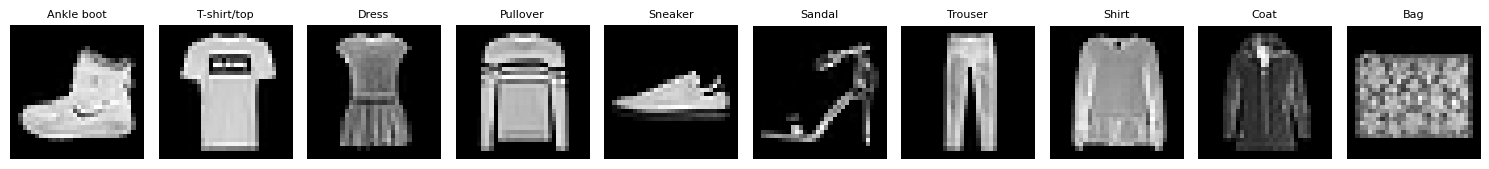

In [ ]:
def visualize_samples(dataset, num_samples=10):
    """可视化数据集中的样本"""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))

    # 每个类别选一个样本
    class_samples = {}
    for img, label in dataset:
        if label not in class_samples:
            class_samples[label] = img
        if len(class_samples) == num_samples:
            break

    for idx, (label, img) in enumerate(class_samples.items()):
        axes[idx].imshow(img.squeeze(), cmap='gray')
        axes[idx].set_title(CLASS_LABELS[label], fontsize=8)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(trainset)

## 10. 验证函数

用于在训练过程中评估模型在验证集上的性能。

In [ ]:
def validate(model, dataloader, device):
    """
    在验证集上评估模型

    参数:
        model: VAE模型
        dataloader: 验证数据加载器
        device: 计算设备

    返回:
        平均验证损失
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            pred = model(data)
            loss = vae_loss(pred, data)
            total_loss += loss.item()

    return total_loss / len(dataloader)

## 11. 模型初始化

In [ ]:
# 创建编码器和解码器
encoder = Encoder(IMAGE_SIZE, EMBEDDING_DIM).to(DEVICE)
decoder = Decoder(EMBEDDING_DIM, SHAPE_BEFORE_FLATTENING).to(DEVICE)

# 创建VAE模型
vae = VAE(encoder, decoder).to(DEVICE)

# 优化器
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR
)

# 学习率调度器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=PATIENCE
)

# 打印模型结构
print("编码器结构:")
print(encoder)
print("\n解码器结构:")
print(decoder)
print(f"\n模型参数总数: {sum(p.numel() for p in vae.parameters()):,}")

编码器结构:
Encoder(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_mean): Linear(in_features=2048, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=2048, out_features=2, bias=True)
  (sampling): Sampling()
)

解码器结构:
Decoder(
  (fc): Linear(in_features=2, out_features=2048, bias=True)
  (deconv1): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (deconv2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (deconv3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
)

模型参数总数: 199,557


## 12. 训练前重构效果

先看看未经训练的模型重构效果如何。

/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missi

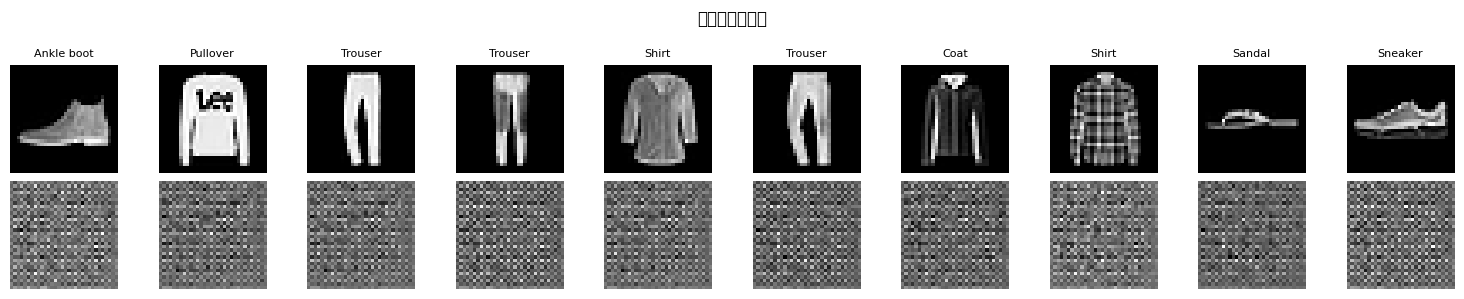

In [ ]:
def visualize_reconstruction(model, dataloader, device, num_images=10, title="重构结果"):
    """可视化原始图像和重构图像的对比"""
    model.eval()

    # 获取一批数据
    data, labels = next(iter(dataloader))
    data = data[:num_images].to(device)
    labels = labels[:num_images]

    with torch.no_grad():
        _, _, recon = model(data)

    # 转换为numpy用于显示
    data = data.cpu().numpy()
    recon = recon.cpu().numpy()

    fig, axes = plt.subplots(2, num_images, figsize=(15, 3))

    for i in range(num_images):
        # 原始图像
        axes[0, i].imshow(data[i].squeeze(), cmap='gray')
        axes[0, i].set_title(CLASS_LABELS[labels[i].item()], fontsize=8)
        axes[0, i].axis('off')

        # 重构图像
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('原始', fontsize=10)
    axes[1, 0].set_ylabel('重构', fontsize=10)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 训练前的重构效果
visualize_reconstruction(vae, test_loader, DEVICE, title="训练前重构效果")

## 13. 训练 VAE

现在训练模型。训练过程包括：
1. 前向传播：计算重构和损失
2. 反向传播：更新模型参数
3. 验证：评估模型性能
4. 保存最佳模型

In [ ]:
# 训练循环
best_val_loss = float('inf')
train_losses = []
val_losses = []

print("开始训练VAE...")
print("=" * 50)

for epoch in range(EPOCHS):
    # 训练模式
    vae.train()
    running_loss = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(DEVICE)

        # 清零梯度
        optimizer.zero_grad()

        # 前向传播
        pred = vae(data)

        # 计算损失
        loss = vae_loss(pred, data)

        # 反向传播
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 计算平均训练损失
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # 验证
    val_loss = validate(vae, test_loader, DEVICE)
    val_losses.append(val_loss)

    # 打印进度
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")

    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'vae': vae.state_dict(),
            'encoder': encoder.state_dict(),
            'decoder': decoder.state_dict(),
        }, 'best_vae.pt')

    # 调整学习率
    scheduler.step(val_loss)

print("=" * 50)
print(f"训练完成！最佳验证损失: {best_val_loss:.4f}")

开始训练VAE...
Epoch [1/50] | Train Loss: 145.2513 | Val Loss: 136.9342
Epoch [6/50] | Train Loss: 132.3050 | Val Loss: 132.9007
Epoch [11/50] | Train Loss: 131.0220 | Val Loss: 131.8152
Epoch [16/50] | Train Loss: 130.2793 | Val Loss: 131.3743
Epoch [21/50] | Train Loss: 128.9794 | Val Loss: 130.3663
Epoch [26/50] | Train Loss: 128.8365 | Val Loss: 130.2513
Epoch [31/50] | Train Loss: 128.6763 | Val Loss: 130.1769
Epoch [36/50] | Train Loss: 128.5055 | Val Loss: 130.0547
Epoch [41/50] | Train Loss: 128.5064 | Val Loss: 130.0516
Epoch [46/50] | Train Loss: 128.5109 | Val Loss: 130.0588
Epoch [50/50] | Train Loss: 128.4902 | Val Loss: 130.0342
训练完成！最佳验证损失: 130.0342


## 14. 绘制训练曲线

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  fig.canvas

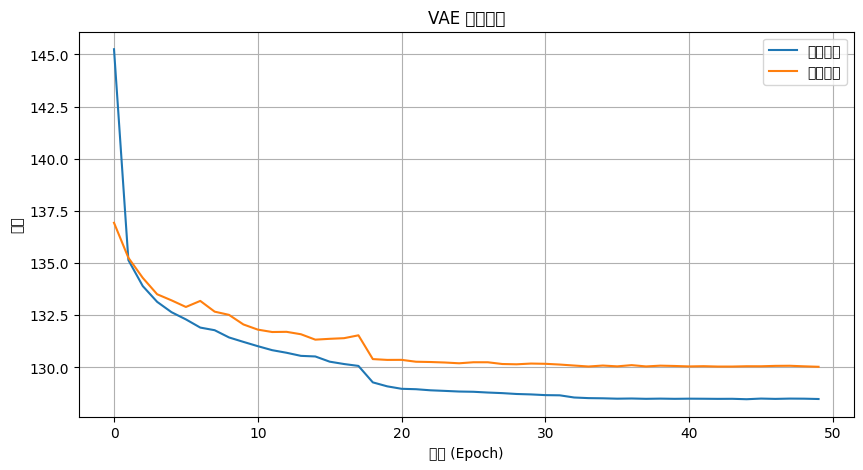

In [ ]:
# 绘制训练和验证损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='训练损失')
plt.plot(val_losses, label='验证损失')
plt.xlabel('轮次 (Epoch)')
plt.ylabel('损失')
plt.title('VAE 训练曲线')
plt.legend()
plt.grid(True)
plt.show()

## 15. 训练后重构效果

对比训练前后的重构效果。

/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/534187666.py:33: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missi

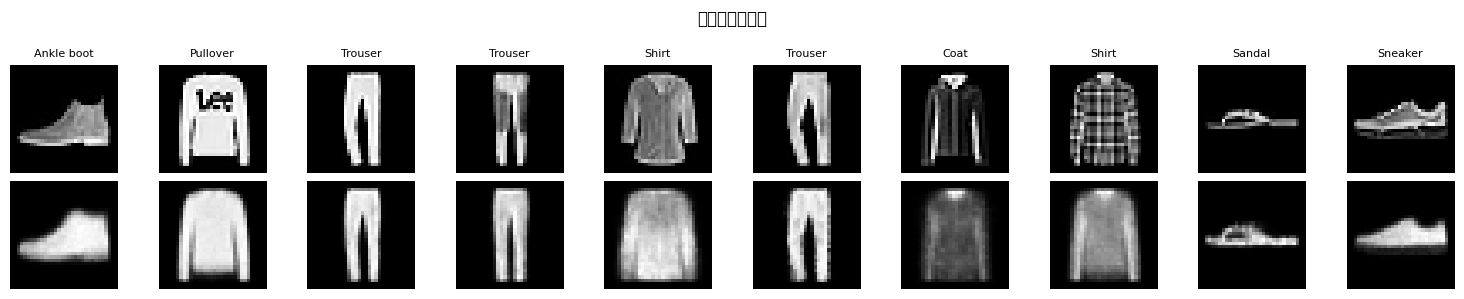

In [ ]:
# 加载最佳模型
checkpoint = torch.load('best_vae.pt', map_location=DEVICE)
vae.load_state_dict(checkpoint['vae'])

# 训练后的重构效果
visualize_reconstruction(vae, test_loader, DEVICE, title="训练后重构效果")

## 16. 潜在空间可视化

由于我们使用了2维潜在空间，可以直接可视化。观察：
- 不同类别的聚类情况
- 潜在空间是否符合标准正态分布
- 类别之间的边界是否清晰

/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/1553625174.py:50: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}

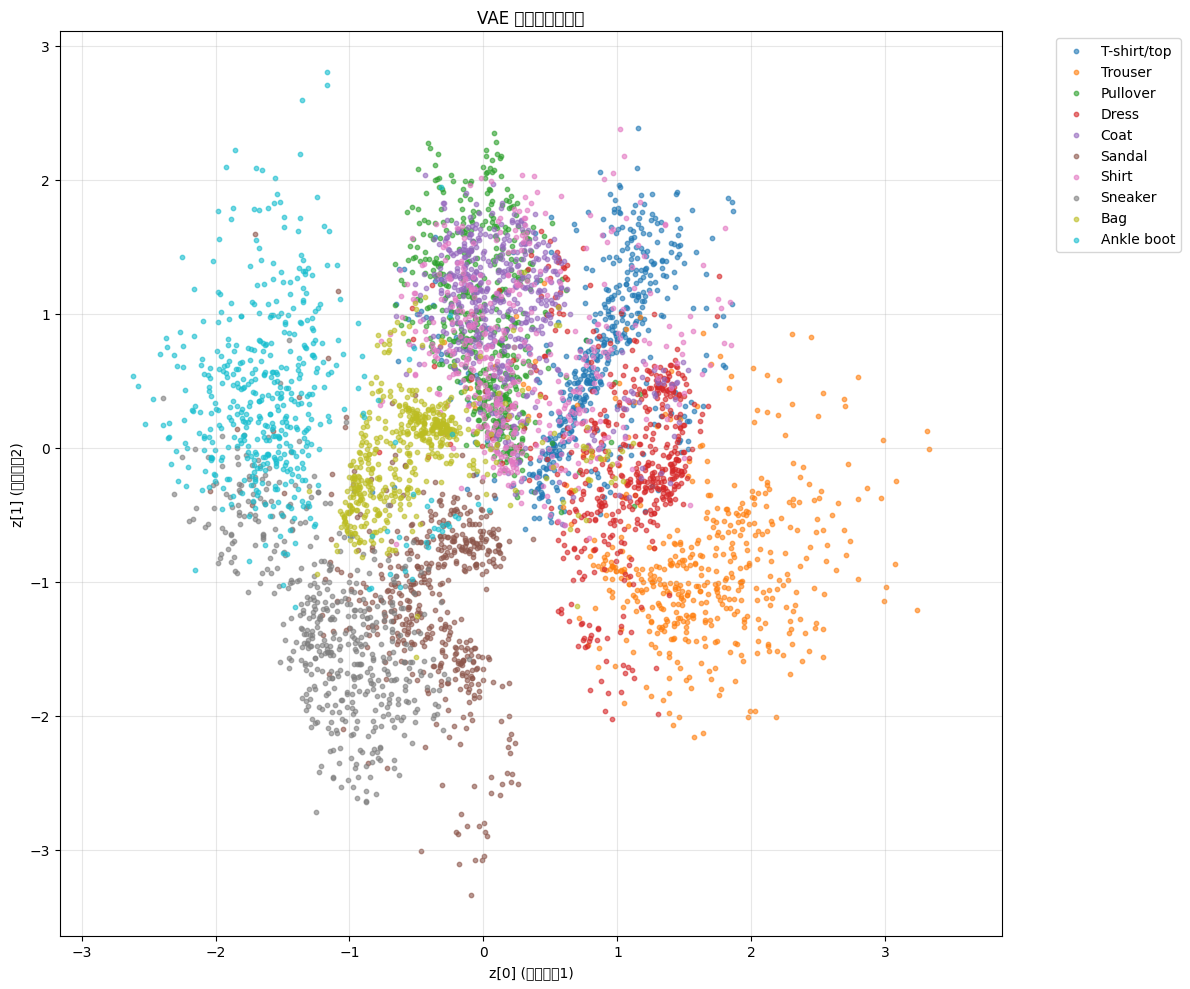

In [ ]:
def get_embeddings(model, dataloader, device, max_samples=5000):
    """
    获取测试集的潜在空间嵌入

    返回:
        embeddings: [N, 2] 潜在向量
        labels: [N] 类别标签
    """
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            z_mean, _, _ = model.encode(data)
            embeddings.append(z_mean.cpu())
            labels.append(target)

            if len(embeddings) * dataloader.batch_size >= max_samples:
                break

    embeddings = torch.cat(embeddings, dim=0)[:max_samples]
    labels = torch.cat(labels, dim=0)[:max_samples]

    return embeddings.numpy(), labels.numpy()


def plot_latent_space(embeddings, labels, title="VAE 潜在空间可视化"):
    """绘制潜在空间散点图"""
    plt.figure(figsize=(12, 10))

    # 为每个类别绘制散点
    for i in range(10):
        mask = labels == i
        plt.scatter(
            embeddings[mask, 0],
            embeddings[mask, 1],
            label=CLASS_LABELS[i],
            alpha=0.6,
            s=10
        )

    plt.xlabel('z[0] (潜在维度1)')
    plt.ylabel('z[1] (潜在维度2)')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


# 获取嵌入并可视化
embeddings, labels = get_embeddings(vae, test_loader, DEVICE)
plot_latent_space(embeddings, labels)

## 17. 潜在空间分布分析

检查潜在空间是否服从标准正态分布。

/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/909081622.py:21: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39057 (\N

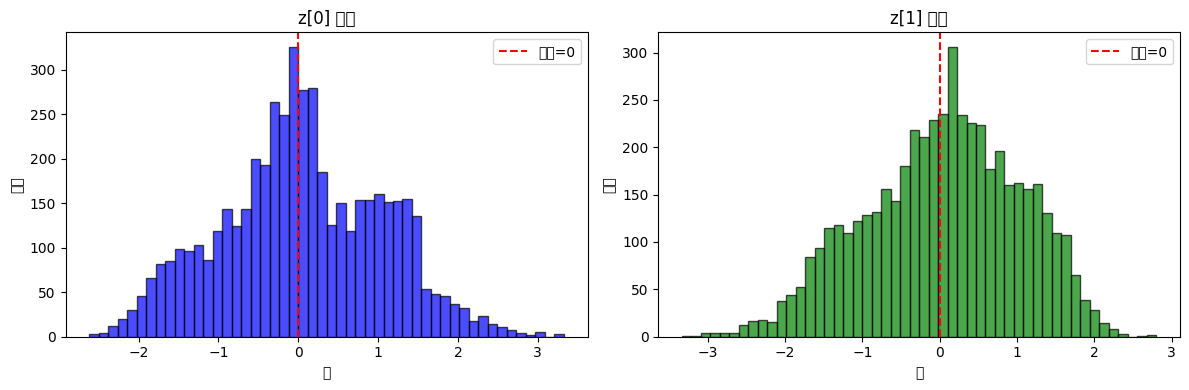

潜在空间统计:
  z[0] 均值: 0.0426, 标准差: 1.0147
  z[1] 均值: 0.0330, 标准差: 1.0041


In [ ]:
def plot_latent_distribution(embeddings):
    """绘制潜在空间的分布直方图"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # z[0]的分布
    axes[0].hist(embeddings[:, 0], bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('z[0] 分布')
    axes[0].set_xlabel('值')
    axes[0].set_ylabel('频数')
    axes[0].axvline(0, color='red', linestyle='--', label='均值=0')
    axes[0].legend()

    # z[1]的分布
    axes[1].hist(embeddings[:, 1], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('z[1] 分布')
    axes[1].set_xlabel('值')
    axes[1].set_ylabel('频数')
    axes[1].axvline(0, color='red', linestyle='--', label='均值=0')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print("潜在空间统计:")
    print(f"  z[0] 均值: {embeddings[:, 0].mean():.4f}, 标准差: {embeddings[:, 0].std():.4f}")
    print(f"  z[1] 均值: {embeddings[:, 1].mean():.4f}, 标准差: {embeddings[:, 1].std():.4f}")

plot_latent_distribution(embeddings)

## 18. 线性插值生成图像

在潜在空间中进行线性插值，观察从一个类别到另一个类别的平滑过渡。这展示了VAE潜在空间的连续性。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  fig.canvas

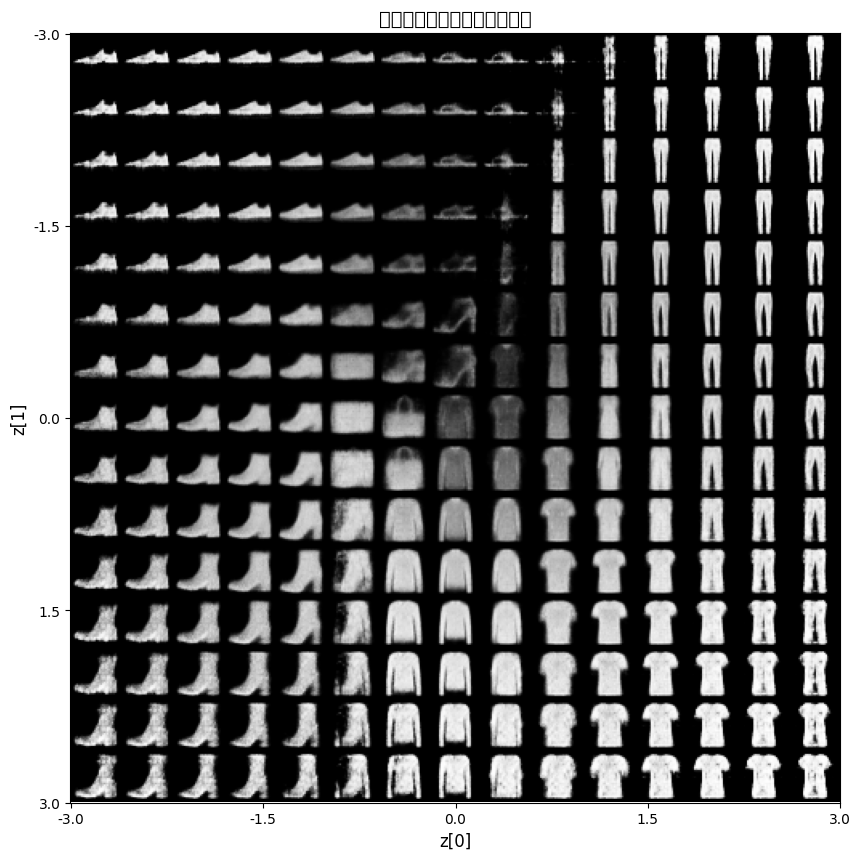

In [ ]:
def plot_image_grid_on_embeddings(model, device, n=15, min_val=-3, max_val=3):
    """
    在潜在空间的网格上生成图像

    参数:
        n: 网格大小 (n x n)
        min_val, max_val: 潜在空间的取值范围
    """
    model.eval()

    # 创建网格
    grid_x = np.linspace(min_val, max_val, n)
    grid_y = np.linspace(min_val, max_val, n)

    # 存储生成的图像
    figure = np.zeros((IMAGE_SIZE * n, IMAGE_SIZE * n))

    with torch.no_grad():
        for i, yi in enumerate(grid_x):
            for j, xi in enumerate(grid_y):
                # 潜在向量
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)

                # 生成图像
                img = model.generate(z)
                img = img.cpu().numpy()[0, 0]

                # 放入网格
                figure[i * IMAGE_SIZE: (i + 1) * IMAGE_SIZE,
                       j * IMAGE_SIZE: (j + 1) * IMAGE_SIZE] = img

    # 绘制
    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.xlabel('z[0]', fontsize=12)
    plt.ylabel('z[1]', fontsize=12)
    plt.title('潜在空间网格采样生成的图像', fontsize=14)

    # 设置刻度
    tick_positions = np.linspace(0, IMAGE_SIZE * n, 5)
    tick_labels = np.linspace(min_val, max_val, 5)
    plt.xticks(tick_positions, [f'{x:.1f}' for x in tick_labels])
    plt.yticks(tick_positions, [f'{y:.1f}' for y in tick_labels])

    plt.show()


# 生成潜在空间网格图像
plot_image_grid_on_embeddings(vae, DEVICE, n=15, min_val=-3, max_val=3)

## 19. 从正态分布采样生成新图像

这是VAE的核心能力：从标准正态分布采样潜在向量，然后解码生成全新的、训练集中不存在的图像。

/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2082926039.py:26: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}

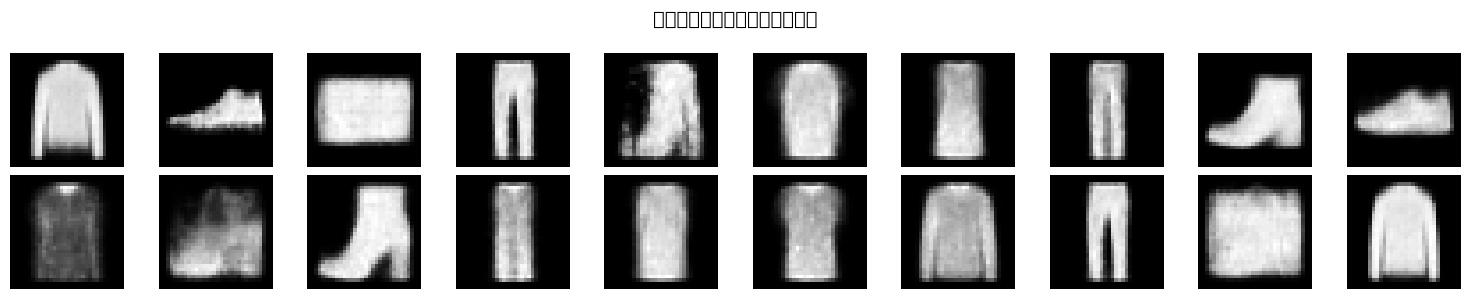

In [ ]:
def generate_from_normal_distribution(model, device, num_samples=20):
    """
    从标准正态分布采样生成图像

    这展示了VAE的生成能力
    """
    model.eval()

    # 从标准正态分布采样
    z_samples = torch.randn(num_samples, EMBEDDING_DIM).to(device)

    with torch.no_grad():
        generated = model.generate(z_samples)

    generated = generated.cpu().numpy()

    # 显示生成的图像
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    axes = axes.flatten()

    for i in range(num_samples):
        axes[i].imshow(generated[i, 0], cmap='gray')
        axes[i].axis('off')

    plt.suptitle('从标准正态分布采样生成的图像', fontsize=14)
    plt.tight_layout()
    plt.show()

    return z_samples


# 生成图像
z_samples = generate_from_normal_distribution(vae, DEVICE)

## 20. 两图像之间的插值

选择两个测试图像，在它们的潜在表示之间进行线性插值，观察平滑过渡效果。

/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 25554 (\N{CJK UNIFIED IDEOGRAPH-63D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4609/2430360634.py:45: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 255

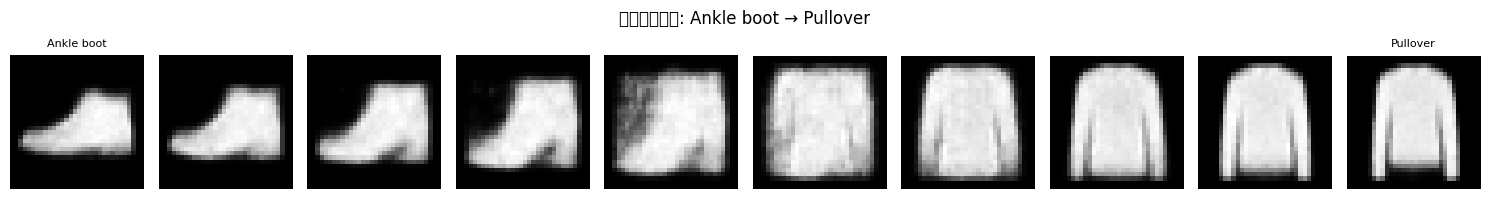

In [ ]:
def interpolate_between_images(model, dataloader, device, num_steps=10):
    """
    在两个随机测试图像之间进行插值
    """
    model.eval()

    # 获取两个不同的测试图像
    data_iter = iter(dataloader)
    data, labels = next(data_iter)

    # 选择两个不同类别的图像
    img1, label1 = data[0], labels[0]
    for i in range(1, len(data)):
        if labels[i] != label1:
            img2, label2 = data[i], labels[i]
            break

    # 编码到潜在空间
    with torch.no_grad():
        z1_mean, _, _ = model.encode(img1.unsqueeze(0).to(device))
        z2_mean, _, _ = model.encode(img2.unsqueeze(0).to(device))

    # 线性插值
    alphas = np.linspace(0, 1, num_steps)
    interpolated_images = []

    with torch.no_grad():
        for alpha in alphas:
            z_interp = (1 - alpha) * z1_mean + alpha * z2_mean
            img_interp = model.generate(z_interp)
            interpolated_images.append(img_interp.cpu().numpy()[0, 0])

    # 显示插值结果
    fig, axes = plt.subplots(1, num_steps, figsize=(15, 2))

    for i, img in enumerate(interpolated_images):
        axes[i].imshow(img, cmap='gray')
        if i == 0:
            axes[i].set_title(f'{CLASS_LABELS[label1.item()]}', fontsize=8)
        elif i == num_steps - 1:
            axes[i].set_title(f'{CLASS_LABELS[label2.item()]}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(f'潜在空间插值: {CLASS_LABELS[label1.item()]} → {CLASS_LABELS[label2.item()]}')
    plt.tight_layout()
    plt.show()


# 执行插值
interpolate_between_images(vae, test_loader, DEVICE, num_steps=10)

## 21. 总结

本Notebook展示了变分自编码器（VAE）的完整实现和分析：

### 关键概念

1. **概率潜在空间**：与传统自编码器不同，VAE的编码器输出分布参数（均值和方差），而非固定点

2. **重参数化技巧**：使得通过随机采样操作进行反向传播成为可能

3. **损失函数组成**：
   - 重构损失：保证解码图像质量
   - KL散度：约束潜在空间接近标准正态分布

### 实验结果

1. **重构能力**：训练后的VAE能够较好地重构输入图像

2. **潜在空间结构**：
   - 各类别形成聚类
   - 分布接近标准正态分布（均值为0，标准差为1）
   - 空间连续，适合插值

3. **生成能力**：可以从标准正态分布采样生成新的时尚物品图像

### VAE vs CAE

| 方面 | VAE优势 |
|------|---------|
| 生成能力 | 可以从分布中采样生成新图像 |
| 插值连续性 | 潜在空间连续，插值结果平滑 |
| 分布特性 | 符合标准正态分布，采样有理论指导 |
| 训练稳定性 | KL散度作为正则化，训练更稳定 |

### 参考

- Kingma, D. P., & Welling, M. (2013). Auto-Encoding Variational Bayes. arXiv:1312.6114.
- [PyImageSearch VAE Tutorial](https://pyimagesearch.com/2023/10/02/a-deep-dive-into-variational-autoencoders-with-pytorch/)